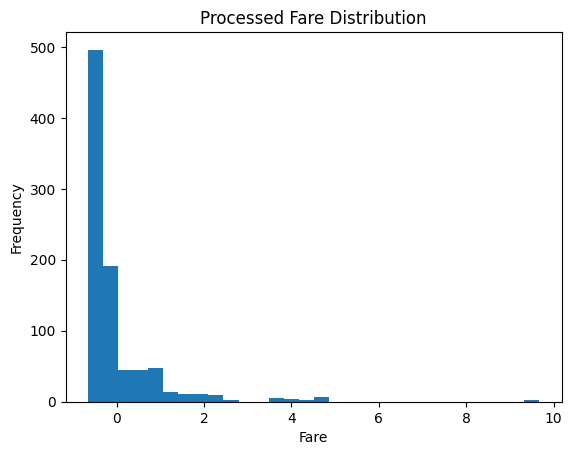

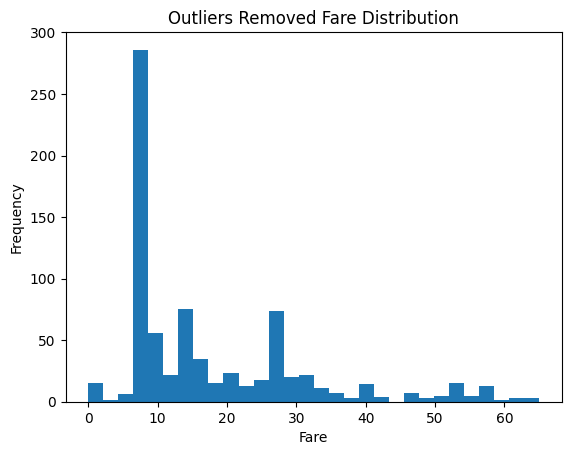

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

# Load Dataset
data = pd.read_csv("/content/Titanic-Dataset.csv")

# Median Imputation
data['Age_median'] = data['Age'].fillna(data['Age'].median())

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
data[['Age']] = imputer.fit_transform(data[['Age']])

# Outlier Detection using IQR
Q1 = data['Fare'].quantile(0.25)
Q3 = data['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping
data['Fare_capped'] = np.where(data['Fare'] > upper, upper,
                        np.where(data['Fare'] < lower, lower, data['Fare']))

# Removal
data_removed = data[(data['Fare'] >= lower) & (data['Fare'] <= upper)]

# Feature Scaling
scaler = StandardScaler()
num_cols = ['Age', 'Fare']
data[num_cols] = scaler.fit_transform(data[num_cols])

# Save Preprocessed Dataset
data.to_csv("processed_titanic.csv", index=False)

# Visualization
plt.figure()
plt.hist(data['Fare'], bins=30)
plt.title("Processed Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(data_removed['Fare'], bins=30)
plt.title("Outliers Removed Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()